In [42]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)

In [43]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features:", X.shape)
print("Target:", y.shape)
print("Classes:", data.target_names)

Features: (569, 30)
Target: (569,)
Classes: ['malignant' 'benign']


In [44]:
print("Feature names:\n")
print(data.feature_names)

print("\nFirst patient:\n")
print(X[0])

print("\nTarget:", y[0])

Feature names:

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

First patient:

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]

Target: 0


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test =  scaler.fit_transform(X_test)

In [47]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)

y_test = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

In [48]:
class LogisticRegression(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):

        x = self.linear(x)
        x = torch.sigmoid(x)

        return x

In [49]:
model = LogisticRegression(input_dim=30)

loss_fn = nn.BCELoss()

optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [50]:
epochs = 500

loss_history = []

for epoch in range(epochs):

    predictions = model(X_train)

    loss = loss_fn(
        predictions,
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch} | Loss: {loss.item():.4f}"
        )

Epoch 0 | Loss: 0.8322
Epoch 50 | Loss: 0.3477
Epoch 100 | Loss: 0.2578
Epoch 150 | Loss: 0.2170
Epoch 200 | Loss: 0.1927
Epoch 250 | Loss: 0.1762
Epoch 300 | Loss: 0.1641
Epoch 350 | Loss: 0.1547
Epoch 400 | Loss: 0.1472
Epoch 450 | Loss: 0.1410


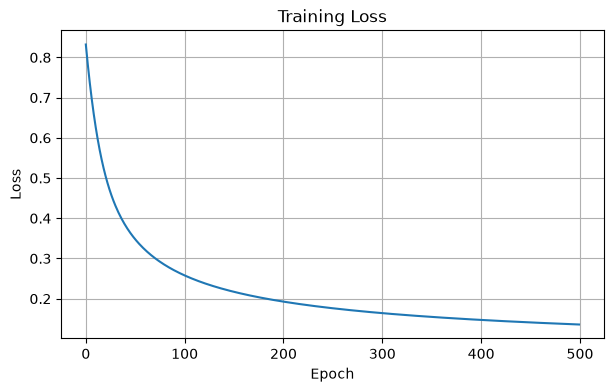

In [51]:
plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)
plt.show()

In [52]:
with torch.no_grad():

    probabilities = model(X_test)

print(probabilities[:5])

tensor([[0.8139],
        [0.0193],
        [0.1574],
        [0.9455],
        [0.9842]])


In [53]:
predictions = (probabilities >= 0.5).float()

In [ ]:
accuracy = (predictions == y_test).float().mean()

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.37%


In [ ]:
cm = confusion_matrix(y_test.numpy(),predictions.numpy())

print(cm)

[[40  3]
 [ 0 71]]


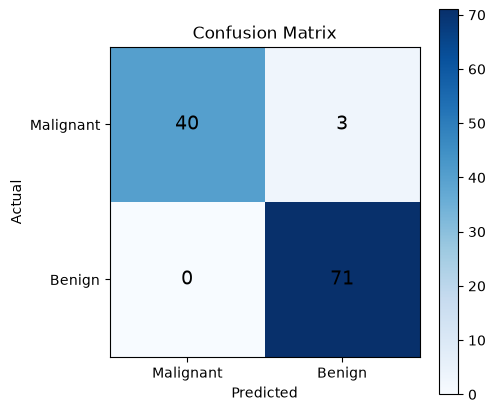

In [56]:
plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.xticks([0,1], ["Malignant","Benign"])
plt.yticks([0,1], ["Malignant","Benign"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            color="black",
            fontsize=14
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()
plt.show()

In [57]:
tp = cm[1,1]
tn = cm[0,0]
fp = cm[0,1]
fn = cm[1,0]

precision = tp / (tp + fp)
recall = tp / (tp + fn)

f1 = 2 * precision * recall / (precision + recall)

print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")

Precision : 0.959
Recall    : 1.000
F1 Score  : 0.979


In [58]:
with torch.no_grad():

    sample = X_test[0].unsqueeze(0)

    probability = model(sample)

    prediction = (probability >= 0.5).float()

print("Probability:", probability.item())
print("Prediction:", "Benign" if prediction.item() == 1 else "Malignant")
print("Actual:", "Benign" if y_test[0].item() == 1 else "Malignant")

Probability: 0.8139494061470032
Prediction: Benign
Actual: Benign
